# 초기 리뷰 기간 범위 설정 — 상관계수 분석
## 목적
출시 후 몇 개월치 리뷰까지를 **"초기"** 로 정의할 것인가에 대한 데이터 기반 근거를 마련한다.

## 분석 방법
- 구간별(1/2/3/6개월) 초기 리뷰 수 집계
- 초기 리뷰 수 vs 흥행 지표 간 **Spearman 상관계수** 계산
- 구간 추가 시 상관계수 **증분** 확인 → 변곡점 = 초기 기간 기준

## 흥행 지표 2가지
| 지표 | 대상 | 설명 |
|------|------|------|
| `total_reviews` | 전체 74개 | 누적 리뷰 수 — 인기의 간접 지표 |
| `owners_lower` | large_high + mid_high 54개 | 소유자 수 하한 — small_high는 전부 0이라 제외 |

## 사용 파일
- `review_histogram_v4.csv`
- `steam_stratified_sample_v4.csv`


## 1. 라이브러리 로드

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")


라이브러리 로드 완료


## 2. 데이터 로드 및 전처리

In [ ]:
# ── 파일 로드 ────────────────────────────────────────────
df     = pd.read_csv("../../../data/steam_indie_review_histogram.csv")
sample = pd.read_csv("../../../data/steam_stratified_sample.csv")

# ── 날짜 파싱 및 경과 월 계산 ─────────────────────────────
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['date_dt']      = pd.to_datetime(df['date'], unit='s')
df['months_since_release'] = (
    (df['date_dt'] - df['release_date']).dt.days / 30.44
).round(1)

# ── sample에서 흥행 지표 매칭 (appid 기준) ────────────────
appid_to_reviews = dict(zip(sample['appid'], sample['total_reviews']))
appid_to_owners  = dict(zip(sample['appid'], sample['owners_lower']))

df['total_reviews'] = df['appid'].map(appid_to_reviews)
df['owners_lower']  = df['appid'].map(appid_to_owners)

print(f"histogram 게임 수 : {df['appid'].nunique()}개")
print(f"sample 게임 수    : {sample['appid'].nunique()}개")
print(f"매칭 성공         : {df['total_reviews'].notna().any()}")
print(f"total_reviews NaN : {df['total_reviews'].isna().sum()}개")
print(f"owners_lower NaN  : {df['owners_lower'].isna().sum()}개")


histogram 게임 수 : 74개
sample 게임 수    : 160개
매칭 성공         : True
total_reviews NaN : 0개
owners_lower NaN  : 0개


## 3. rollups 전처리

In [10]:
# rollups(월별 집계)만 사용
rollups = df[df['data_type'] == 'rollups'].copy()
rollups['month_int'] = rollups['months_since_release'].apply(lambda x: int(x // 1))
rollups['total']     = rollups['recommendations_up'] + rollups['recommendations_down']

rollups = (
    rollups
    .groupby(
        ['appid', 'name', 'stratum', 'month_int',
         'release_date', 'total_reviews', 'owners_lower'],
        as_index=False
    )[['recommendations_up', 'recommendations_down', 'total']].sum()
    .sort_values(['appid', 'month_int'])
)

print(f"rollups shape: {rollups.shape}")
print()
print("=== 층별 흥행 지표 분포 ===")
game_info = rollups.drop_duplicates('appid')
print(game_info.groupby('stratum')[['total_reviews','owners_lower']].describe().round(0))


rollups shape: (2329, 10)

=== 층별 흥행 지표 분포 ===
           total_reviews                                                     \
                   count     mean      std     min     25%     50%      75%   
stratum                                                                       
large_high          29.0  18434.0  34179.0  1191.0  4386.0  6132.0  14229.0   
mid_high            25.0   1117.0   1051.0   383.0   537.0   705.0   1214.0   
small_high          20.0    516.0    145.0   403.0   437.0   447.0    508.0   

                     owners_lower                                          \
                 max        count      mean       std       min       25%   
stratum                                                                     
large_high  153566.0         29.0  572414.0  939565.0  200000.0  200000.0   
mid_high      5090.0         25.0   45200.0   25020.0   20000.0   20000.0   
small_high     912.0         20.0       0.0       0.0       0.0       0.0   

               

## 4. 구간별 초기 리뷰 수 집계

In [11]:
WINDOWS = [1, 2, 3, 6]

results = []
for appid, group in rollups.groupby('appid'):
    after = group[group['month_int'] >= 0]
    for months in WINDOWS:
        window = after[after['month_int'] <= months]
        results.append({
            'appid'        : appid,
            'name'         : group['name'].iloc[0],
            'stratum'      : group['stratum'].iloc[0],
            'total_reviews': group['total_reviews'].iloc[0],
            'owners_lower' : group['owners_lower'].iloc[0],
            'window_months': months,
            'cum_reviews'  : window['total'].sum(),
        })

df_r = pd.DataFrame(results)

print("=== 구간별 초기 리뷰 수 기초통계 ===")
for m in WINDOWS:
    sub = df_r[df_r['window_months'] == m]['cum_reviews']
    print(f"  {m}개월 — 중앙값: {sub.median():.0f}  "
          f"평균: {sub.mean():.0f}  "
          f"최소: {sub.min():.0f}  최대: {sub.max():.0f}")


=== 구간별 초기 리뷰 수 기초통계 ===
  1개월 — 중앙값: 384  평균: 3336  최소: 0  최대: 86007
  2개월 — 중앙값: 422  평균: 3772  최소: 0  최대: 91831
  3개월 — 중앙값: 454  평균: 4095  최소: 0  최대: 96128
  6개월 — 중앙값: 533  평균: 4790  최소: 0  최대: 102745


## 5. Spearman 상관계수 분석

### Spearman을 쓰는 이유
- 데이터가 **비정규 분포** (소수 흥행작이 극단적으로 큼)
- 실제 값 대신 **순위** 기반으로 계산 → 분포 가정 불필요
- `owners_lower` 가 SteamSpy 추정치여도 **순서 관계는 유지** 되므로 적합


In [12]:
corr_results = {'total_reviews': [], 'owners_lower': []}

# ── 분석 1: total_reviews 기준 (전체 74개) ────────────────
print("=" * 72)
print("Spearman r — 초기 리뷰 수 vs total_reviews (전체 74개)")
print("=" * 72)
print(f"{'구간':<8} {'r':>7}  {'p값':>9}  {'Δr':>8}  {'Δr/월':>8}")
print("-" * 72)
prev_r = None
prev_m = None
for m in WINDOWS:
    sub  = df_r[df_r['window_months'] == m]
    r, p = stats.spearmanr(sub['cum_reviews'], sub['total_reviews'])
    if prev_r is not None:
        incr           = r - prev_r
        window_len     = m - prev_m
        incr_per_month = incr / window_len
        incr_str       = f"+{incr:.3f}"
        ipm_str        = f"+{incr_per_month:.3f}"
    else:
        incr = incr_per_month = None
        incr_str = ipm_str = "—"
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"  {m}개월   {r:>7.3f}  {p:>9.4f}  {incr_str:>8}  {ipm_str:>8}  {sig}")
    corr_results['total_reviews'].append(
        {'months': m, 'r': r, 'p': p,
         'incr': incr, 'incr_per_month': incr_per_month}
    )
    prev_r, prev_m = r, m

# ── 분석 2: owners_lower 기준 (large_high + mid_high) ─────
print()
print("=" * 72)
print("Spearman r — 초기 리뷰 수 vs owners_lower")
print("(large_high + mid_high 54개, small_high 제외)")
print("=" * 72)
print(f"{'구간':<8} {'r':>7}  {'p값':>9}  {'Δr':>8}  {'Δr/월':>8}")
print("-" * 72)
prev_r = None
prev_m = None
for m in WINDOWS:
    sub  = df_r[
        (df_r['window_months'] == m) &
        (df_r['stratum'].isin(['large_high', 'mid_high']))
    ]
    r, p = stats.spearmanr(sub['cum_reviews'], sub['owners_lower'])
    if prev_r is not None:
        incr           = r - prev_r
        window_len     = m - prev_m
        incr_per_month = incr / window_len
        incr_str       = f"+{incr:.3f}"
        ipm_str        = f"+{incr_per_month:.3f}"
    else:
        incr = incr_per_month = None
        incr_str = ipm_str = "—"
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"  {m}개월   {r:>7.3f}  {p:>9.4f}  {incr_str:>8}  {ipm_str:>8}  {sig}")
    corr_results['owners_lower'].append(
        {'months': m, 'r': r, 'p': p,
         'incr': incr, 'incr_per_month': incr_per_month}
    )
    prev_r, prev_m = r, m

print()
print("*** p<0.001  ** p<0.01  * p<0.05")

Spearman r — 초기 리뷰 수 vs total_reviews (전체 74개)
구간             r         p값        Δr      Δr/월
------------------------------------------------------------------------
  1개월     0.739     0.0000         —         —  ***
  2개월     0.765     0.0000    +0.026    +0.026  ***
  3개월     0.782     0.0000    +0.017    +0.017  ***
  6개월     0.810     0.0000    +0.028    +0.009  ***

Spearman r — 초기 리뷰 수 vs owners_lower
(large_high + mid_high 54개, small_high 제외)
구간             r         p값        Δr      Δr/월
------------------------------------------------------------------------
  1개월     0.656     0.0000         —         —  ***
  2개월     0.688     0.0000    +0.033    +0.033  ***
  3개월     0.700     0.0000    +0.012    +0.012  ***
  6개월     0.730     0.0000    +0.030    +0.010  ***

*** p<0.001  ** p<0.01  * p<0.05


## 6. 시각화

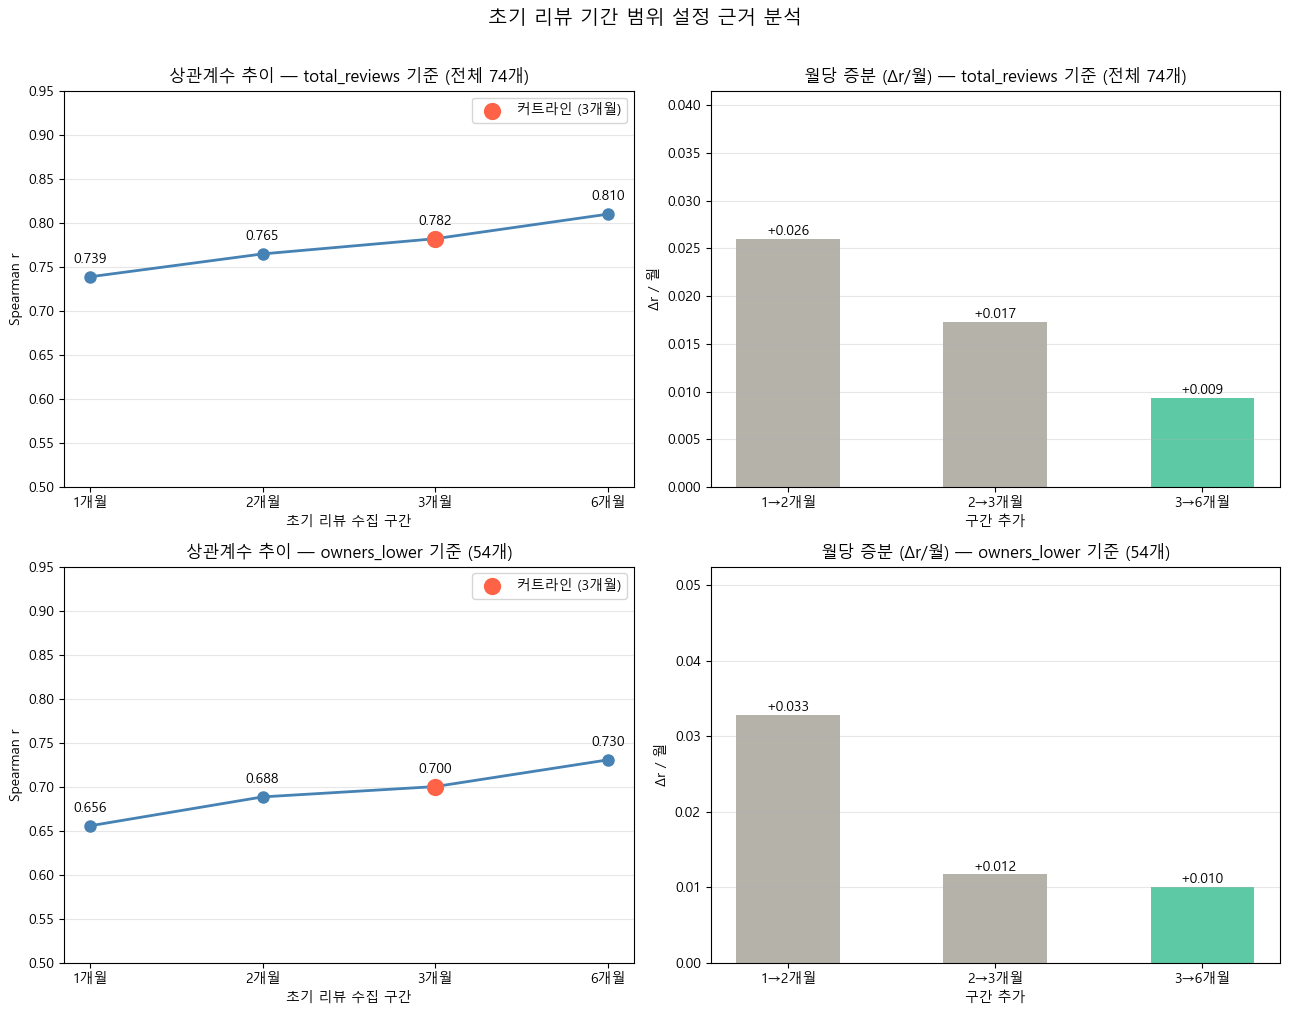

저장 완료 → corr_analysis_v4.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
months_labels = [f"{m}개월" for m in WINDOWS]

for idx, (metric, label) in enumerate([
    ('total_reviews', 'total_reviews 기준 (전체 74개)'),
    ('owners_lower',  'owners_lower 기준 (54개)'),
]):
    cr     = corr_results[metric]
    r_vals = [c['r'] for c in cr]
    ipms   = [c['incr_per_month'] for c in cr if c['incr_per_month'] is not None]
    incr_labels = [f"{WINDOWS[i-1]}→{WINDOWS[i]}개월" for i in range(1, len(WINDOWS))]

    # ── 상관계수 추이 ──────────────────────────────────────
    ax1 = axes[idx][0]
    ax1.plot(months_labels, r_vals, marker='o', linewidth=2,
             color='steelblue', markersize=8)

    # 커트라인: 월당 효율 최저 구간의 시작점
    min_ipm_idx  = ipms.index(min(ipms))
    cutoff_month = months_labels[min_ipm_idx]      # 3개월 (비효율 구간 시작)
    ax1.scatter([cutoff_month], [r_vals[min_ipm_idx]],
                color='tomato', s=130, zorder=5, label=f'커트라인 ({cutoff_month})')

    for label_m, r in zip(months_labels, r_vals):
        ax1.annotate(f'{r:.3f}', (label_m, r),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=10)

    ax1.set_ylim(0.5, 0.95)
    ax1.set_title(f'상관계수 추이 — {label}', fontsize=12)
    ax1.set_xlabel('초기 리뷰 수집 구간')
    ax1.set_ylabel('Spearman r')
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)

    # ── 월당 증분 ─────────────────────────────────────────
    ax2    = axes[idx][1]
    colors = ['#5DCAA5' if v == min(ipms) else '#B4B2A9' for v in ipms]
    bars   = ax2.bar(incr_labels, ipms, color=colors, width=0.5)

    for bar, val in zip(bars, ipms):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f'+{val:.3f}', ha='center', fontsize=10)

    ax2.set_ylim(0, max(ipms) * 1.6)
    ax2.set_title(f'월당 증분 (Δr/월) — {label}', fontsize=12)
    ax2.set_xlabel('구간 추가')
    ax2.set_ylabel('Δr / 월')
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('초기 리뷰 기간 범위 설정 근거 분석', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. 결론

In [14]:
print("=" * 60)
print("증분 분석 결과 요약 (월당 Δr 기준)")
print("=" * 60)

for metric, label in [
    ('total_reviews', 'total_reviews 기준'),
    ('owners_lower',  'owners_lower 기준'),
]:
    cr = corr_results[metric]
    print(f"\n[{label}]")
    for c in cr:
        if c['incr'] is not None:
            prev_m     = WINDOWS[WINDOWS.index(c['months']) - 1]
            window_len = c['months'] - prev_m
            print(f"  {prev_m}→{c['months']}개월: "
                  f"Δr = +{c['incr']:.3f} "
                  f"({window_len}개월 구간, 월당 +{c['incr_per_month']:.3f})")

    # 월당 효율 최저 구간 탐지
    incrs_only = [(c['months'], c['incr_per_month']) for c in cr if c['incr_per_month'] is not None]
    worst      = min(incrs_only, key=lambda x: x[1])
    cutoff_m   = WINDOWS[WINDOWS.index(worst[0]) - 1]
    print(f"  → 월당 효율 최저 구간: {cutoff_m}→{worst[0]}개월 (월당 +{worst[1]:.3f})")
    print(f"  → 커트라인: {cutoff_m}개월")

print()
print("=" * 60)
print("결론: 초기 리뷰 기간 = 3개월")
print("=" * 60)
print("두 지표 모두 3→6개월 구간의 월당 증분이 가장 낮음.")
print("3개월 이후 1개월 추가 대비 예측력 향상이 가장 미미함.")

증분 분석 결과 요약 (월당 Δr 기준)

[total_reviews 기준]
  1→2개월: Δr = +0.026 (1개월 구간, 월당 +0.026)
  2→3개월: Δr = +0.017 (1개월 구간, 월당 +0.017)
  3→6개월: Δr = +0.028 (3개월 구간, 월당 +0.009)
  → 월당 효율 최저 구간: 3→6개월 (월당 +0.009)
  → 커트라인: 3개월

[owners_lower 기준]
  1→2개월: Δr = +0.033 (1개월 구간, 월당 +0.033)
  2→3개월: Δr = +0.012 (1개월 구간, 월당 +0.012)
  3→6개월: Δr = +0.030 (3개월 구간, 월당 +0.010)
  → 월당 효율 최저 구간: 3→6개월 (월당 +0.010)
  → 커트라인: 3개월

결론: 초기 리뷰 기간 = 3개월
두 지표 모두 3→6개월 구간의 월당 증분이 가장 낮음.
3개월 이후 1개월 추가 대비 예측력 향상이 가장 미미함.
